In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, VGG16, EfficientNetB0, DenseNet121
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras import mixed_precision

# Scikit-learn
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# CUDA Configuration
print("="*60)
print("CUDA AND GPU CONFIGURATION")
print("="*60)

# Check TensorFlow version
print(f"\nTensorFlow Version: {tf.__version__}")

# List physical devices
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPU Devices Available: {len(gpus)}")
for gpu in gpus:
    print(f"  - {gpu}")

# Configure GPU memory growth to prevent OOM errors
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("\n✅ GPU memory growth enabled")
    except RuntimeError as e:
        print(f"\n❌ Error setting memory growth: {e}")

# Enable mixed precision for faster training on modern GPUs
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"\n✅ Mixed precision enabled: {policy.name}")
print(f"   Compute dtype: {policy.compute_dtype}")
print(f"   Variable dtype: {policy.variable_dtype}")

# Set TensorFlow to use GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Use first GPU
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

# Verify CUDA is being used
print(f"\nBuilt with CUDA: {tf.test.is_built_with_cuda()}")
print(f"GPU Available: {tf.test.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None)}")

# Check CUDA details
if tf.test.gpu_device_name():
    print(f"\nDefault GPU Device: {tf.test.gpu_device_name()}")
else:
    print("\n⚠️  No GPU detected, using CPU")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure TensorFlow for better GPU utilization
tf.config.optimizer.set_jit(True)  # Enable XLA
print("\n✅ XLA (Accelerated Linear Algebra) enabled")

print("\n" + "="*60)

2026-01-16 16:03:09.770843: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768579389.962824      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768579390.019365      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768579390.486349      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768579390.486398      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768579390.486402      25 computation_placer.cc:177] computation placer alr

CUDA AND GPU CONFIGURATION

TensorFlow Version: 2.19.0

GPU Devices Available: 1
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

✅ GPU memory growth enabled

✅ Mixed precision enabled: mixed_float16
   Compute dtype: float16
   Variable dtype: float32

Built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU Available: True

Default GPU Device: /device:GPU:0

✅ XLA (Accelerated Linear Algebra) enabled



I0000 00:00:1768579402.977028      25 gpu_device.cc:2019] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1768579402.978685      25 gpu_device.cc:2019] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1768579402.979279      25 gpu_device.cc:2019] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [2]:
# Dataset paths
base_path = "/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

# Verify paths
print(f"Train path exists: {os.path.exists(train_path)}")
print(f"Test path exists: {os.path.exists(test_path)}")

# Get class names
class_names = sorted(os.listdir(train_path))
num_classes = len(class_names)
print(f"\nNumber of classes: {num_classes}")
print(f"\nClasses: {class_names}")

# Count images in each class
train_counts = {}
test_counts = {}

for class_name in class_names:
    train_class_path = os.path.join(train_path, class_name)
    test_class_path = os.path.join(test_path, class_name)
    
    if os.path.exists(train_class_path):
        train_counts[class_name] = len(os.listdir(train_class_path))
    if os.path.exists(test_class_path):
        test_counts[class_name] = len(os.listdir(test_class_path))

print(f"\nTotal training images: {sum(train_counts.values())}")
print(f"Total test images: {sum(test_counts.values())}")

Train path exists: True
Test path exists: True

Number of classes: 22

Classes: ['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']

Total training images: 13898
Total test images: 1546


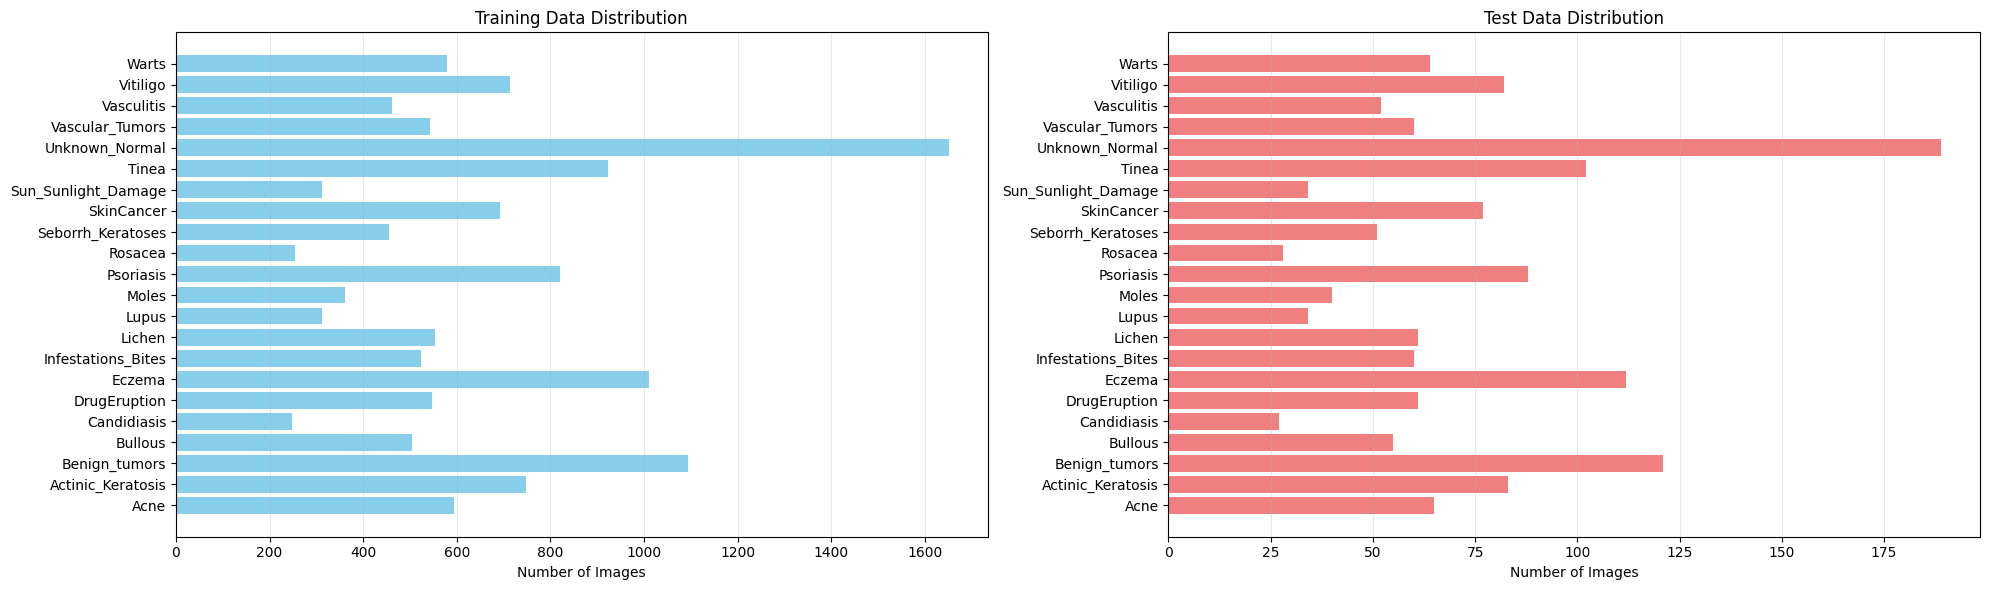

In [3]:
# Visualize class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Training data distribution
ax1.barh(list(train_counts.keys()), list(train_counts.values()), color='skyblue')
ax1.set_xlabel('Number of Images')
ax1.set_title('Training Data Distribution')
ax1.grid(axis='x', alpha=0.3)

# Test data distribution
ax2.barh(list(test_counts.keys()), list(test_counts.values()), color='lightcoral')
ax2.set_xlabel('Number of Images')
ax2.set_title('Test Data Distribution')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Image parameters - optimized for GPU
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32  # Increased batch size for better GPU utilization

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Only rescaling for test data
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators with GPU-optimized settings
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"\nBatch size: {BATCH_SIZE} (optimized for GPU)")
print(f"Training batches per epoch: {len(train_generator)}")
print(f"Validation batches per epoch: {len(validation_generator)}")

Found 11128 images belonging to 22 classes.
Found 2770 images belonging to 22 classes.
Found 1546 images belonging to 22 classes.
Training samples: 11128
Validation samples: 2770
Test samples: 1546

Batch size: 32 (optimized for GPU)
Training batches per epoch: 348
Validation batches per epoch: 87


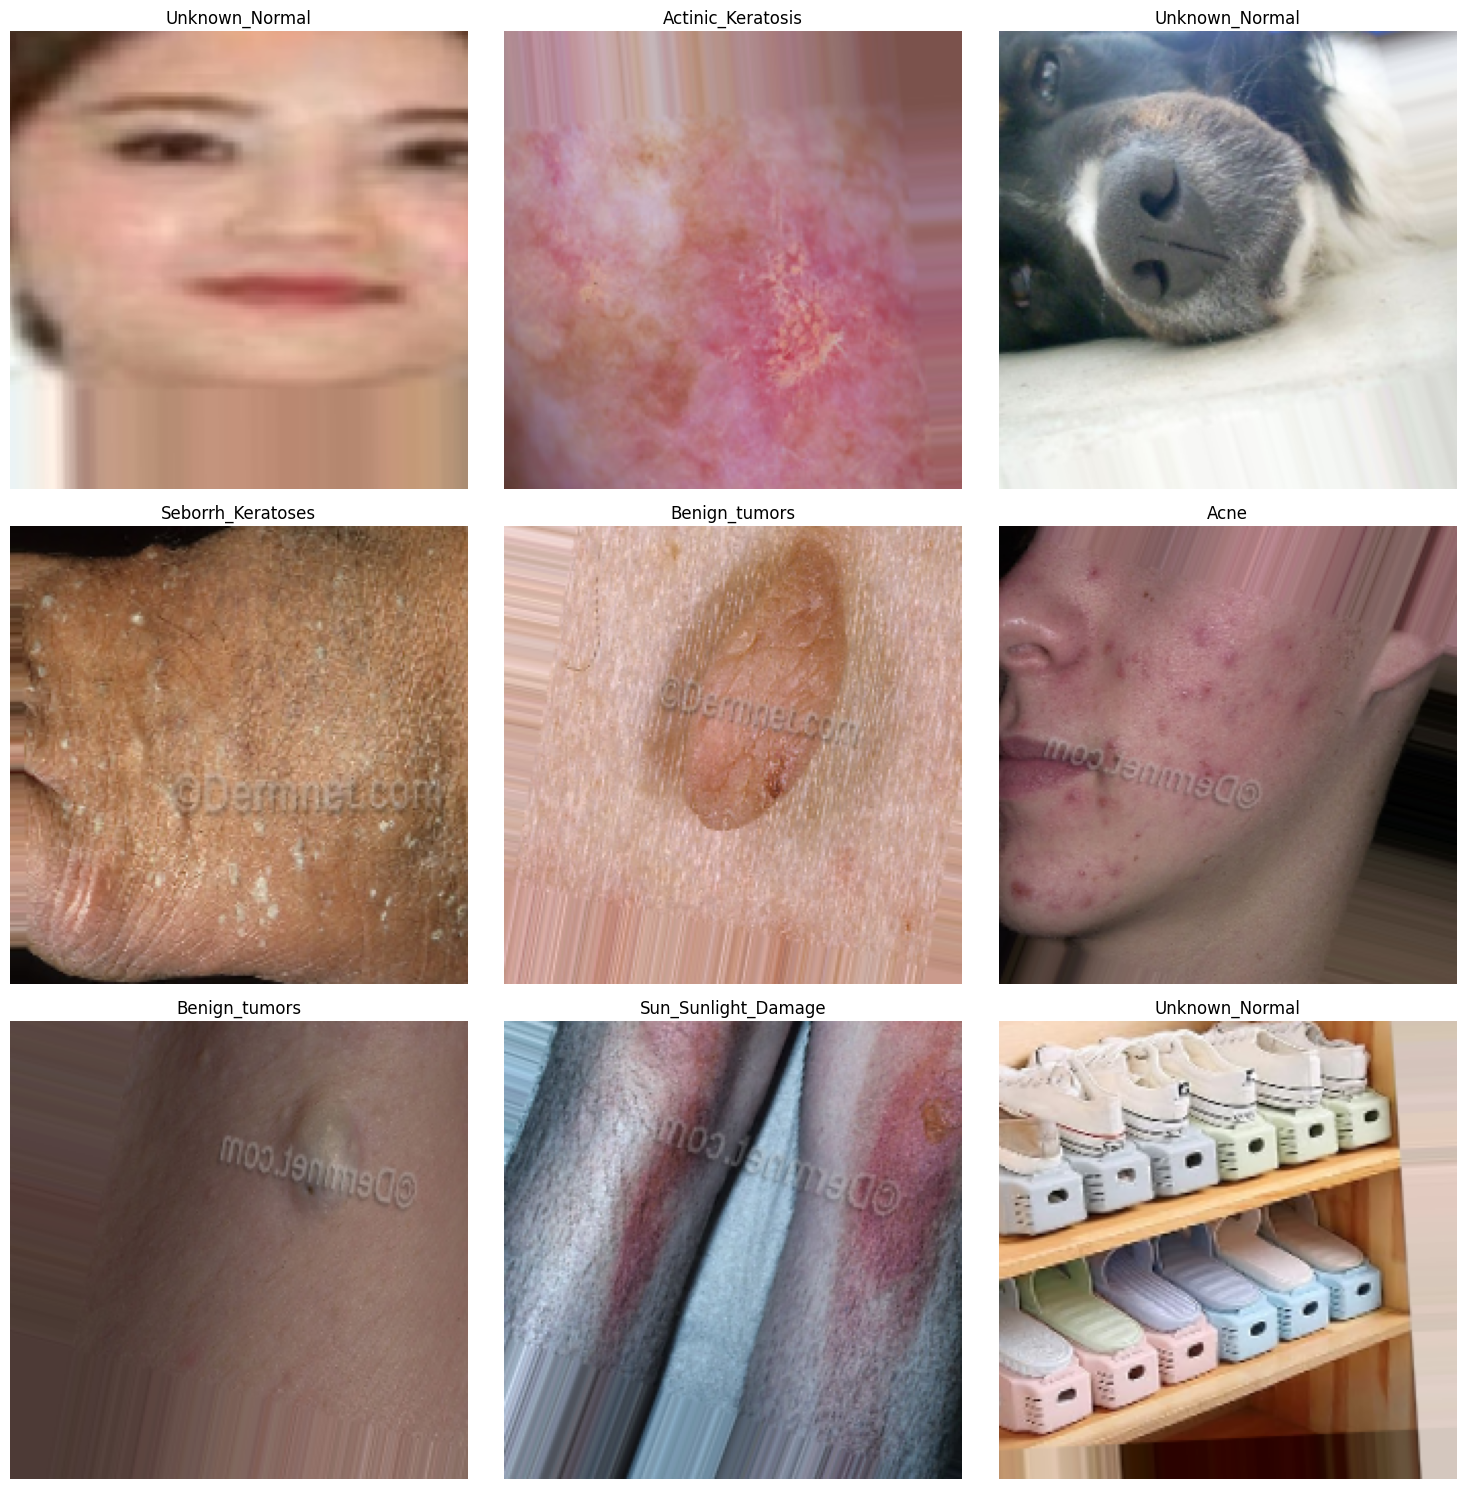

In [5]:
# Display sample images from training set
def display_sample_images(generator, num_images=9):
    images, labels = next(generator)
    
    plt.figure(figsize=(15, 15))
    for i in range(min(num_images, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        class_idx = np.argmax(labels[i])
        plt.title(class_names[class_idx])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

display_sample_images(train_generator)

In [6]:
# MobileNetV2 Model with mixed precision
def create_mobilenet_v2(input_shape=(224, 224, 3), num_classes=22):
    with tf.device('/GPU:0'):
        base_model = MobileNetV2(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
        
        # Freeze base model
        base_model.trainable = False
        
        # Build model
        inputs = keras.Input(shape=input_shape)
        x = base_model(inputs, training=False)
        x = GlobalAveragePooling2D()(x)
        x = Dense(512, activation='relu')(x)
        x = Dropout(0.5)(x)
        x = Dense(256, activation='relu')(x)
        x = Dropout(0.3)(x)
        outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)  #Float32 for numerical stability
        
        model = Model(inputs, outputs)
        
        model.compile(
            optimizer=Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    
    return model

print("Building MobileNetV2 on GPU...")
mobilenet_model = create_mobilenet_v2(num_classes=num_classes)
print(f"✅ MobileNetV2 created on GPU")
mobilenet_model.summary()

Building MobileNetV2 on GPU...


I0000 00:00:1768579421.389434      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ MobileNetV2 created on GPU


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 22)             │         5,654 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,050,838 (11.64 MB)

 Trainable params: 792,854 (3.02 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# DenseNet121 Model with mixed precision
def create_densenet121(input_shape=(224, 224, 3), num_classes=22):
    with tf.device('/GPU:0'):
        base_model = DenseNet121(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
        
        # Freeze base model
        base_model.trainable = False
        
        # Build model
        inputs = keras.Input(shape=input_shape)
        x = base_model(inputs, training=False)
        x = GlobalAveragePooling2D()(x)
        x = Dense(512, activation='relu')(x)
        x = Dropout(0.5)(x)
        x = Dense(256, activation='relu')(x)
        x = Dropout(0.3)(x)
        outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)
        
        model = Model(inputs, outputs)
        
        model.compile(
            optimizer=Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    
    return model

print("Building DenseNet121 on GPU...")
densenet_model = create_densenet121(num_classes=num_classes)
print(f"✅ DenseNet121 created on GPU")
densenet_model.summary()

Building DenseNet121 on GPU...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ DenseNet121 created on GPU


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 22)             │         5,654 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,699,286 (29.37 MB)

 Trainable params: 661,782 (2.52 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [8]:
# VGG16 Model with mixed precision
def create_vgg16(input_shape=(224, 224, 3), num_classes=22):
    with tf.device('/GPU:0'):
        base_model = VGG16(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
        
        # Freeze base model
        base_model.trainable = False
        
        # Build model
        inputs = keras.Input(shape=input_shape)
        x = base_model(inputs, training=False)
        x = Flatten()(x)
        x = Dense(512, activation='relu')(x)
        x = Dropout(0.5)(x)
        x = Dense(256, activation='relu')(x)
        x = Dropout(0.3)(x)
        outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)
        
        model = Model(inputs, outputs)
        
        model.compile(
            optimizer=Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    
    return model

print("Building VGG16 on GPU...")
vgg16_model = create_vgg16(num_classes=num_classes)
print(f"✅ VGG16 created on GPU")
vgg16_model.summary()

Building VGG16 on GPU...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✅ VGG16 created on GPU


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 22)             │         5,654 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,697,238 (105.66 MB)

 Trainable params: 12,982,550 (49.52 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
# EfficientNetB0 Model with mixed precision
def create_efficientnet_b0(input_shape=(224, 224, 3), num_classes=22):
    with tf.device('/GPU:0'):
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
        
        # Freeze base model
        base_model.trainable = False
        
        # Build model
        inputs = keras.Input(shape=input_shape)
        x = base_model(inputs, training=False)
        x = GlobalAveragePooling2D()(x)
        x = Dense(512, activation='relu')(x)
        x = Dropout(0.5)(x)
        x = Dense(256, activation='relu')(x)
        x = Dropout(0.3)(x)
        outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)
        
        model = Model(inputs, outputs)
        
        model.compile(
            optimizer=Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    
    return model

print("Building EfficientNetB0 on GPU...")
efficientnet_model = create_efficientnet_b0(num_classes=num_classes)
print(f"✅ EfficientNetB0 created on GPU")
efficientnet_model.summary()

Building EfficientNetB0 on GPU...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ EfficientNetB0 created on GPU


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 22)             │         5,654 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,842,425 (18.47 MB)

 Trainable params: 792,854 (3.02 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
# Custom CNN Model with mixed precision
def create_custom_cnn(input_shape=(224, 224, 3), num_classes=22):
    with tf.device('/GPU:0'):
        model = Sequential([
            # Block 1
            Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
            BatchNormalization(),
            Conv2D(32, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Dropout(0.25),
            
            # Block 2
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Dropout(0.25),
            
            # Block 3
            Conv2D(128, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(128, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Dropout(0.25),
            
            # Block 4
            Conv2D(256, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(256, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Dropout(0.25),
            
            # Dense layers
            Flatten(),
            Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.5),
            Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(num_classes, activation='softmax', dtype='float32')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    
    return model

print("Building Custom CNN on GPU...")
custom_cnn_model = create_custom_cnn(num_classes=num_classes)
print(f"✅ Custom CNN created on GPU")
custom_cnn_model.summary()

Building Custom CNN on GPU...
✅ Custom CNN created on GPU


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 27,006,774 (103.02 MB)

 Trainable params: 27,003,318 (103.01 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [11]:
# Training function with GPU optimization (Fixed for Keras 3)
def train_model(model, model_name, epochs=25):
    print(f"\n{'='*60}")
    print(f"Training {model_name} on GPU")
    print(f"{'='*60}\n")
    
    # Callbacks
    checkpoint = ModelCheckpoint(
        f'{model_name}_best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
    
    # Train model with GPU
    with tf.device('/GPU:0'):
        history = model.fit(
            train_generator,
            validation_data=validation_generator,
            epochs=epochs,
            callbacks=[checkpoint, early_stopping, reduce_lr],
            verbose=1
        )
    
    return history

# Store results
results = {}

In [12]:
# Train MobileNetV2
print("🚀 Starting MobileNetV2 training on GPU...")
mobilenet_history = train_model(mobilenet_model, "MobileNetV2", epochs=25)
results['MobileNetV2'] = {
    'model': mobilenet_model,
    'history': mobilenet_history
}
print("✅ MobileNetV2 training completed!")

🚀 Starting MobileNetV2 training on GPU...

Training MobileNetV2 on GPU

Epoch 1/25


I0000 00:00:1768579447.745480      88 service.cc:152] XLA service 0x7d5ce40029c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768579447.745533      88 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1768579448.999010      88 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1768579461.569721      88 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 734ms/step - accuracy: 0.1304 - loss: 3.0469
Epoch 1: val_accuracy improved from -inf to 0.26968, saving model to MobileNetV2_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 371s 997ms/step - accuracy: 0.1305 - loss: 3.0463 - val_accuracy: 0.2697 - val_loss: 2.4702 - learning_rate: 1.0000e-04
Epoch 2/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.2677 - loss: 2.4973
Epoch 2: val_accuracy improved from 0.26968 to 0.29350, saving model to MobileNetV2_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 197s 566ms/step - accuracy: 0.2677 - loss: 2.4971 - val_accuracy: 0.2935 - val_loss: 2.3500 - learning_rate: 1.0000e-04
Epoch 3/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.3083 - loss: 2.3064
Epoch 3: val_accuracy improved from 0.29350 to 0.31769, saving model to MobileNetV2_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 194s 559ms/step - accuracy: 0.3083 - loss: 2.3063 - val_accuracy: 0.3177 - val_loss: 2.2679 - learning_rate: 1.0000e-04


In [13]:
# Train DenseNet121
print("🚀 Starting DenseNet121 training on GPU...")
densenet_history = train_model(densenet_model, "DenseNet121", epochs=25)
results['DenseNet121'] = {
    'model': densenet_model,
    'history': densenet_history
}
print("✅ DenseNet121 training completed!")

🚀 Starting DenseNet121 training on GPU...

Training DenseNet121 on GPU

Epoch 1/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.1207 - loss: 3.1593
Epoch 1: val_accuracy improved from -inf to 0.25271, saving model to DenseNet121_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 268s 687ms/step - accuracy: 0.1209 - loss: 3.1586 - val_accuracy: 0.2527 - val_loss: 2.5326 - learning_rate: 1.0000e-04
Epoch 2/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.2500 - loss: 2.5626
Epoch 2: val_accuracy improved from 0.25271 to 0.30578, saving model to DenseNet121_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 199s 573ms/step - accuracy: 0.2500 - loss: 2.5624 - val_accuracy: 0.3058 - val_loss: 2.3657 - learning_rate: 1.0000e-04
Epoch 3/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.2830 - loss: 2.3883
Epoch 3: val_accuracy improved from 0.30578 to 0.31661, saving model to DenseNet121_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 199s 572ms/step - accuracy: 0.2830 - 

In [14]:
# Train VGG16
print("🚀 Starting VGG16 training on GPU...")
vgg16_history = train_model(vgg16_model, "VGG16", epochs=25)
results['VGG16'] = {
    'model': vgg16_model,
    'history': vgg16_history
}
print("✅ VGG16 training completed!")

🚀 Starting VGG16 training on GPU...

Training VGG16 on GPU

Epoch 1/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.1280 - loss: 2.9921
Epoch 1: val_accuracy improved from -inf to 0.21733, saving model to VGG16_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 227s 617ms/step - accuracy: 0.1281 - loss: 2.9917 - val_accuracy: 0.2173 - val_loss: 2.6180 - learning_rate: 1.0000e-04
Epoch 2/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.2025 - loss: 2.6860
Epoch 2: val_accuracy improved from 0.21733 to 0.25560, saving model to VGG16_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 204s 587ms/step - accuracy: 0.2025 - loss: 2.6860 - val_accuracy: 0.2556 - val_loss: 2.5554 - learning_rate: 1.0000e-04
Epoch 3/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.2240 - loss: 2.5931
Epoch 3: val_accuracy improved from 0.25560 to 0.25740, saving model to VGG16_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 207s 594ms/step - accuracy: 0.2240 - loss: 2.5931 - val_accuracy: 0

In [15]:
# Train EfficientNetB0
print("🚀 Starting EfficientNetB0 training on GPU...")
efficientnet_history = train_model(efficientnet_model, "EfficientNetB0", epochs=25)
results['EfficientNetB0'] = {
    'model': efficientnet_model,
    'history': efficientnet_history
}
print("✅ EfficientNetB0 training completed!")

🚀 Starting EfficientNetB0 training on GPU...

Training EfficientNetB0 on GPU

Epoch 1/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.0956 - loss: 3.0399
Epoch 1: val_accuracy improved from -inf to 0.11913, saving model to EfficientNetB0_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 294s 741ms/step - accuracy: 0.0956 - loss: 3.0398 - val_accuracy: 0.1191 - val_loss: 2.9851 - learning_rate: 1.0000e-04
Epoch 2/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.1109 - loss: 3.0098
Epoch 2: val_accuracy did not improve from 0.11913
348/348 ━━━━━━━━━━━━━━━━━━━━ 200s 575ms/step - accuracy: 0.1109 - loss: 3.0097 - val_accuracy: 0.1191 - val_loss: 2.9818 - learning_rate: 1.0000e-04
Epoch 3/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.1116 - loss: 3.0005
Epoch 3: val_accuracy did not improve from 0.11913
348/348 ━━━━━━━━━━━━━━━━━━━━ 199s 572ms/step - accuracy: 0.1116 - loss: 3.0004 - val_accuracy: 0.1191 - val_loss: 2.9808 - learning_rate: 1.0000e-04
Epoch 4/

In [16]:
# Train Custom CNN
print("🚀 Starting Custom CNN training on GPU...")
custom_cnn_history = train_model(custom_cnn_model, "CustomCNN", epochs=25)
results['CustomCNN'] = {
    'model': custom_cnn_model,
    'history': custom_cnn_history
}
print("✅ Custom CNN training completed!")

🚀 Starting Custom CNN training on GPU...

Training CustomCNN on GPU

Epoch 1/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.1225 - loss: 4.8782
Epoch 1: val_accuracy improved from -inf to 0.03502, saving model to CustomCNN_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 282s 693ms/step - accuracy: 0.1226 - loss: 4.8775 - val_accuracy: 0.0350 - val_loss: 6.1710 - learning_rate: 1.0000e-04
Epoch 2/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.1843 - loss: 4.2589
Epoch 2: val_accuracy improved from 0.03502 to 0.06859, saving model to CustomCNN_best_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 204s 584ms/step - accuracy: 0.1844 - loss: 4.2588 - val_accuracy: 0.0686 - val_loss: 6.9168 - learning_rate: 1.0000e-04
Epoch 3/25
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.2064 - loss: 4.0773
Epoch 3: val_accuracy improved from 0.06859 to 0.07184, saving model to CustomCNN_best_model.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05

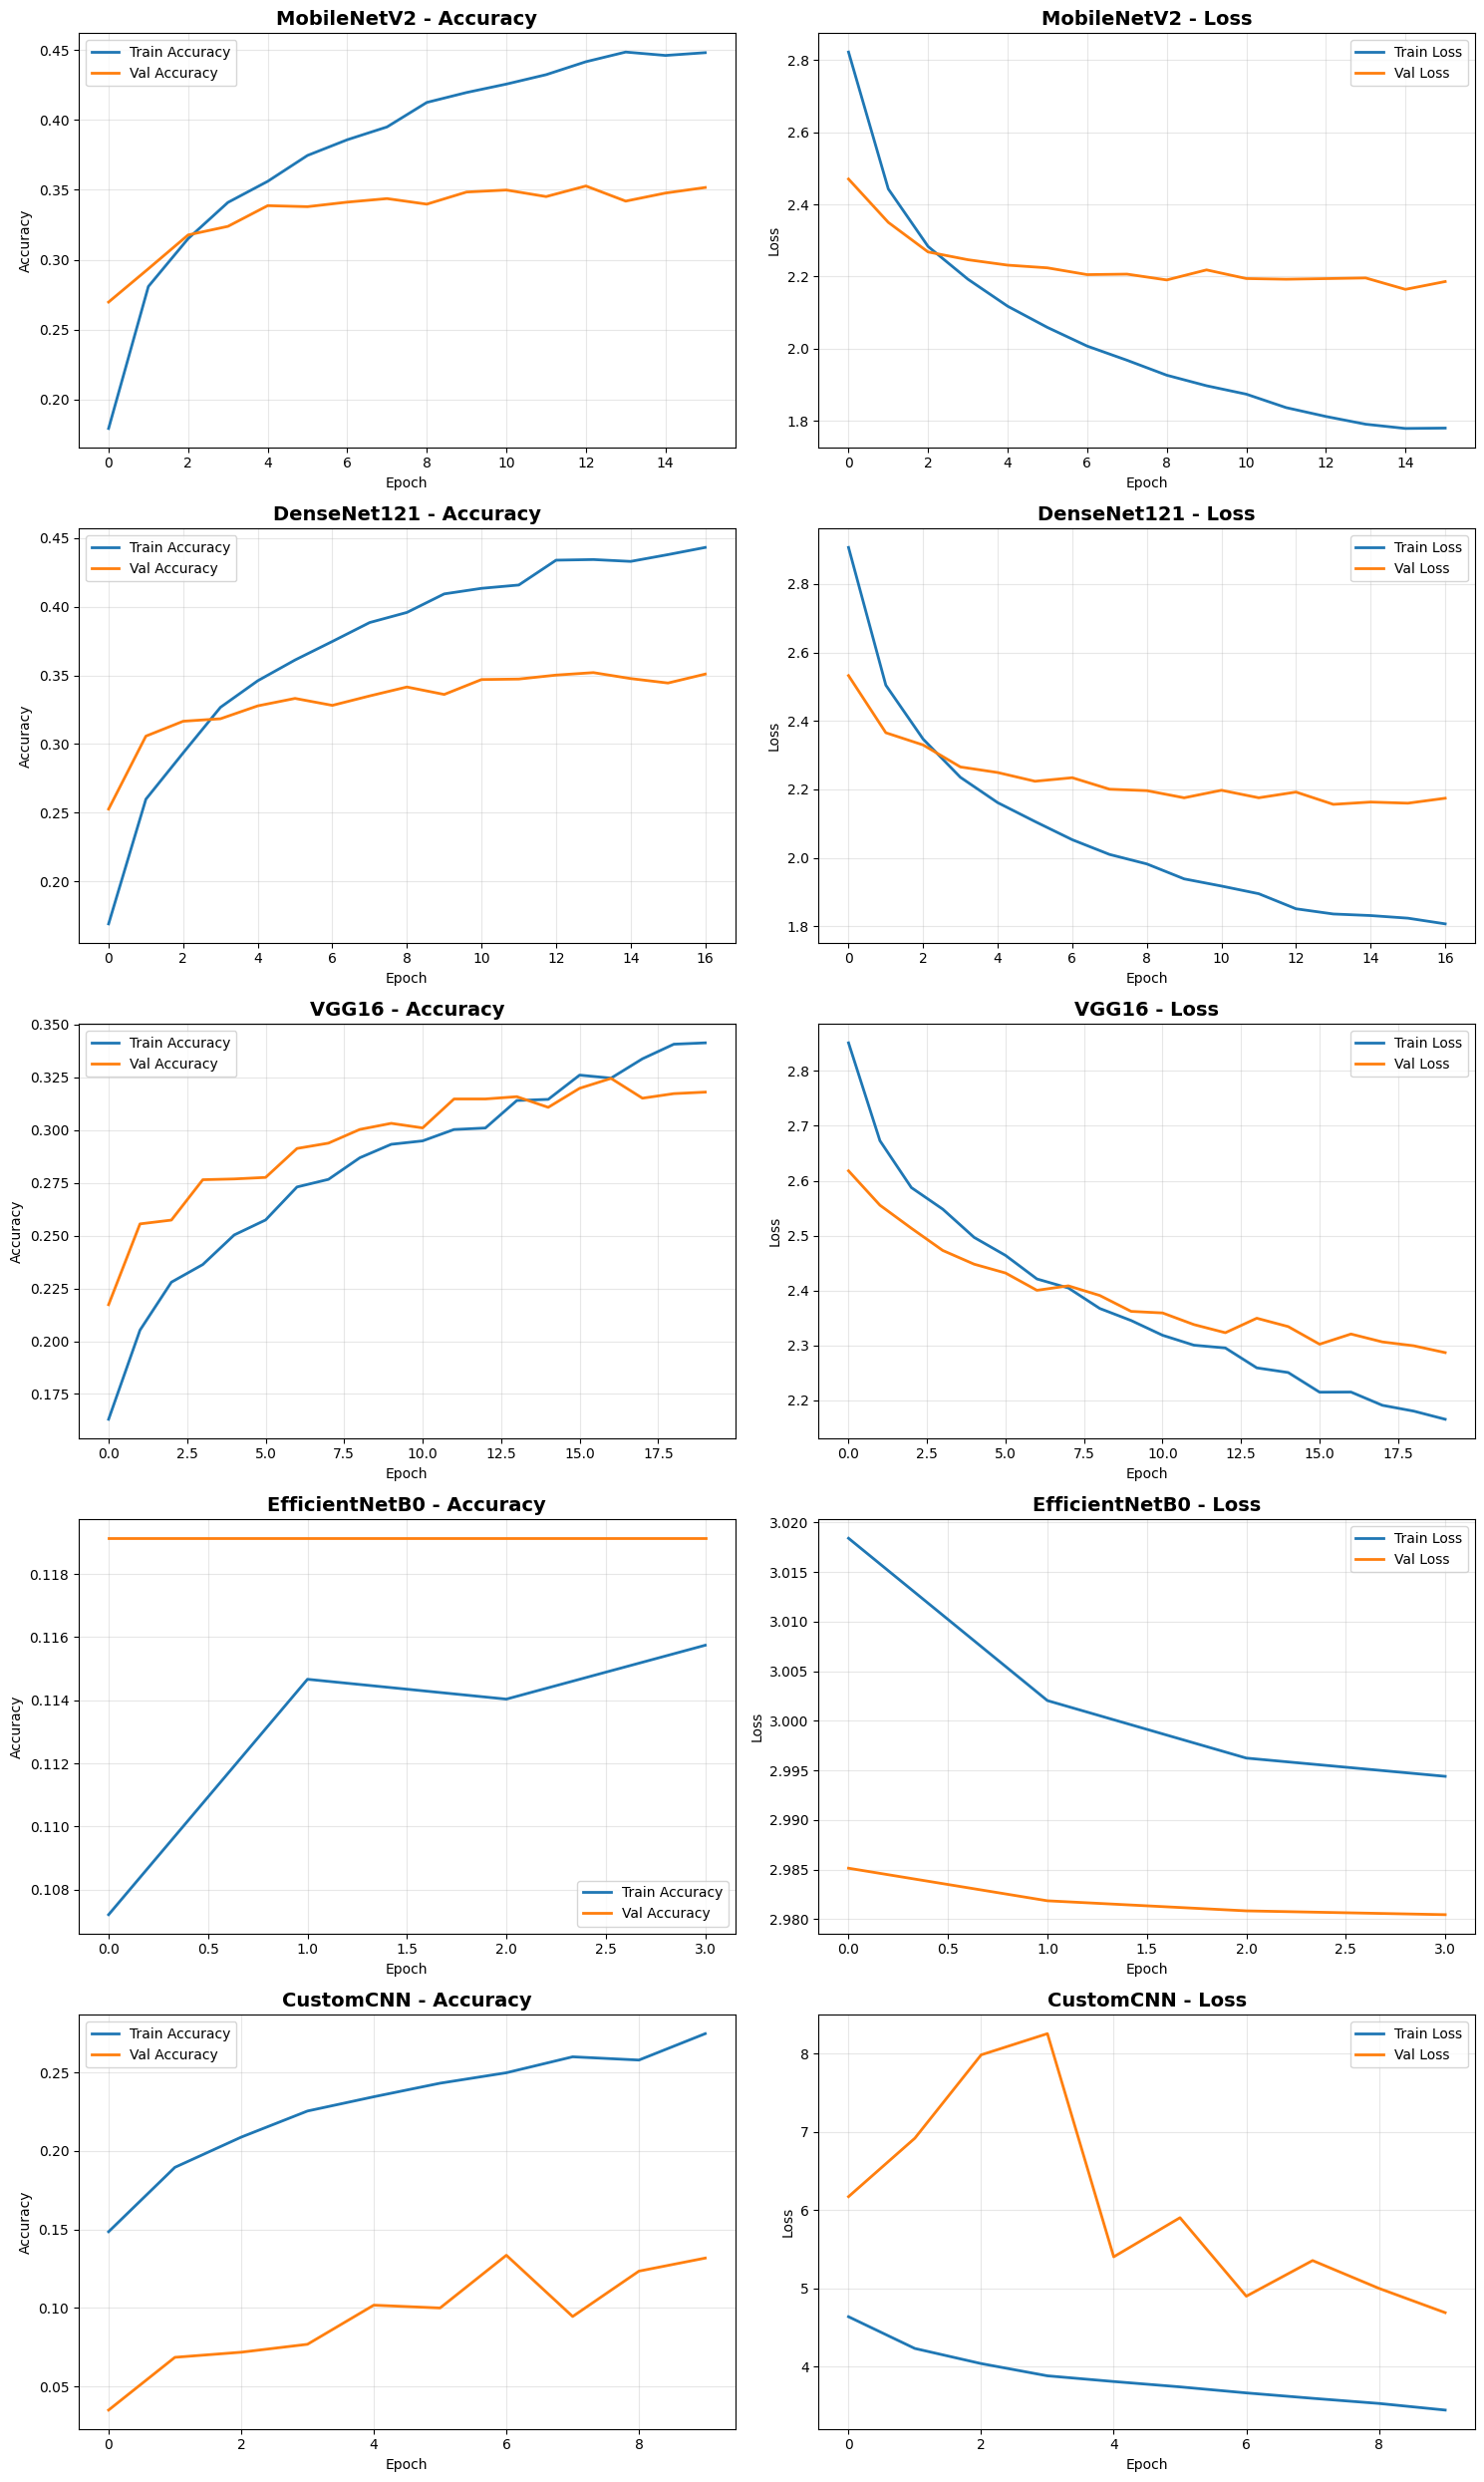

In [17]:
# Plot training history for all models
def plot_training_history(results):
    fig, axes = plt.subplots(len(results), 2, figsize=(15, 5 * len(results)))
    
    if len(results) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (model_name, data) in enumerate(results.items()):
        history = data['history']
        
        # Accuracy plot
        axes[idx, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
        axes[idx, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
        axes[idx, 0].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
        axes[idx, 0].set_xlabel('Epoch')
        axes[idx, 0].set_ylabel('Accuracy')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Loss plot
        axes[idx, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
        axes[idx, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
        axes[idx, 1].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
        axes[idx, 1].set_xlabel('Epoch')
        axes[idx, 1].set_ylabel('Loss')
        axes[idx, 1].legend()
        axes[idx, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(results)

In [18]:
# Evaluate all models on GPU (Fixed for Keras 3)
def evaluate_model(model, model_name):
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name} on Test Set (GPU)")
    print(f"{'='*60}\n")
    
    # Reset test generator
    test_generator.reset()
    
    # Get predictions on GPU
    with tf.device('/GPU:0'):
        predictions = model.predict(
            test_generator, 
            verbose=1
        )
    
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes
    
    # Calculate accuracy
    test_accuracy = accuracy_score(y_true, y_pred)
    print(f"\n✅ Test Accuracy: {test_accuracy:.4f}")
    
    return y_true, y_pred, test_accuracy

# Evaluate all models
evaluation_results = {}

for model_name, data in results.items():
    y_true, y_pred, test_acc = evaluate_model(data['model'], model_name)
    evaluation_results[model_name] = {
        'y_true': y_true,
        'y_pred': y_pred,
        'test_accuracy': test_acc
    }


Evaluating MobileNetV2 on Test Set (GPU)

49/49 ━━━━━━━━━━━━━━━━━━━━ 44s 704ms/step

✅ Test Accuracy: 0.4386

Evaluating DenseNet121 on Test Set (GPU)

49/49 ━━━━━━━━━━━━━━━━━━━━ 35s 483ms/step

✅ Test Accuracy: 0.4586

Evaluating VGG16 on Test Set (GPU)

49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 245ms/step

✅ Test Accuracy: 0.3765

Evaluating EfficientNetB0 on Test Set (GPU)

49/49 ━━━━━━━━━━━━━━━━━━━━ 41s 591ms/step

✅ Test Accuracy: 0.1223

Evaluating CustomCNN on Test Set (GPU)

49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step

✅ Test Accuracy: 0.1436


In [19]:
# Generate classification reports
for model_name, data in evaluation_results.items():
    print(f"\n{'='*60}")
    print(f"Classification Report - {model_name}")
    print(f"{'='*60}\n")
    
    report = classification_report(
        data['y_true'],
        data['y_pred'],
        target_names=class_names,
        digits=4
    )
    print(report)


Classification Report - MobileNetV2

                     precision    recall  f1-score   support

               Acne     0.5067    0.5846    0.5429        65
  Actinic_Keratosis     0.5833    0.3373    0.4275        83
      Benign_tumors     0.2632    0.4132    0.3215       121
            Bullous     0.5200    0.2364    0.3250        55
        Candidiasis     0.3889    0.2593    0.3111        27
       DrugEruption     0.6129    0.3115    0.4130        61
             Eczema     0.2905    0.5446    0.3789       112
 Infestations_Bites     0.2759    0.1333    0.1798        60
             Lichen     0.5000    0.1639    0.2469        61
              Lupus     0.1818    0.0588    0.0889        34
              Moles     0.2029    0.3500    0.2569        40
          Psoriasis     0.3968    0.2841    0.3311        88
            Rosacea     0.4146    0.6071    0.4928        28
  Seborrh_Keratoses     0.4500    0.3529    0.3956        51
         SkinCancer     0.3788    0.3247    0.

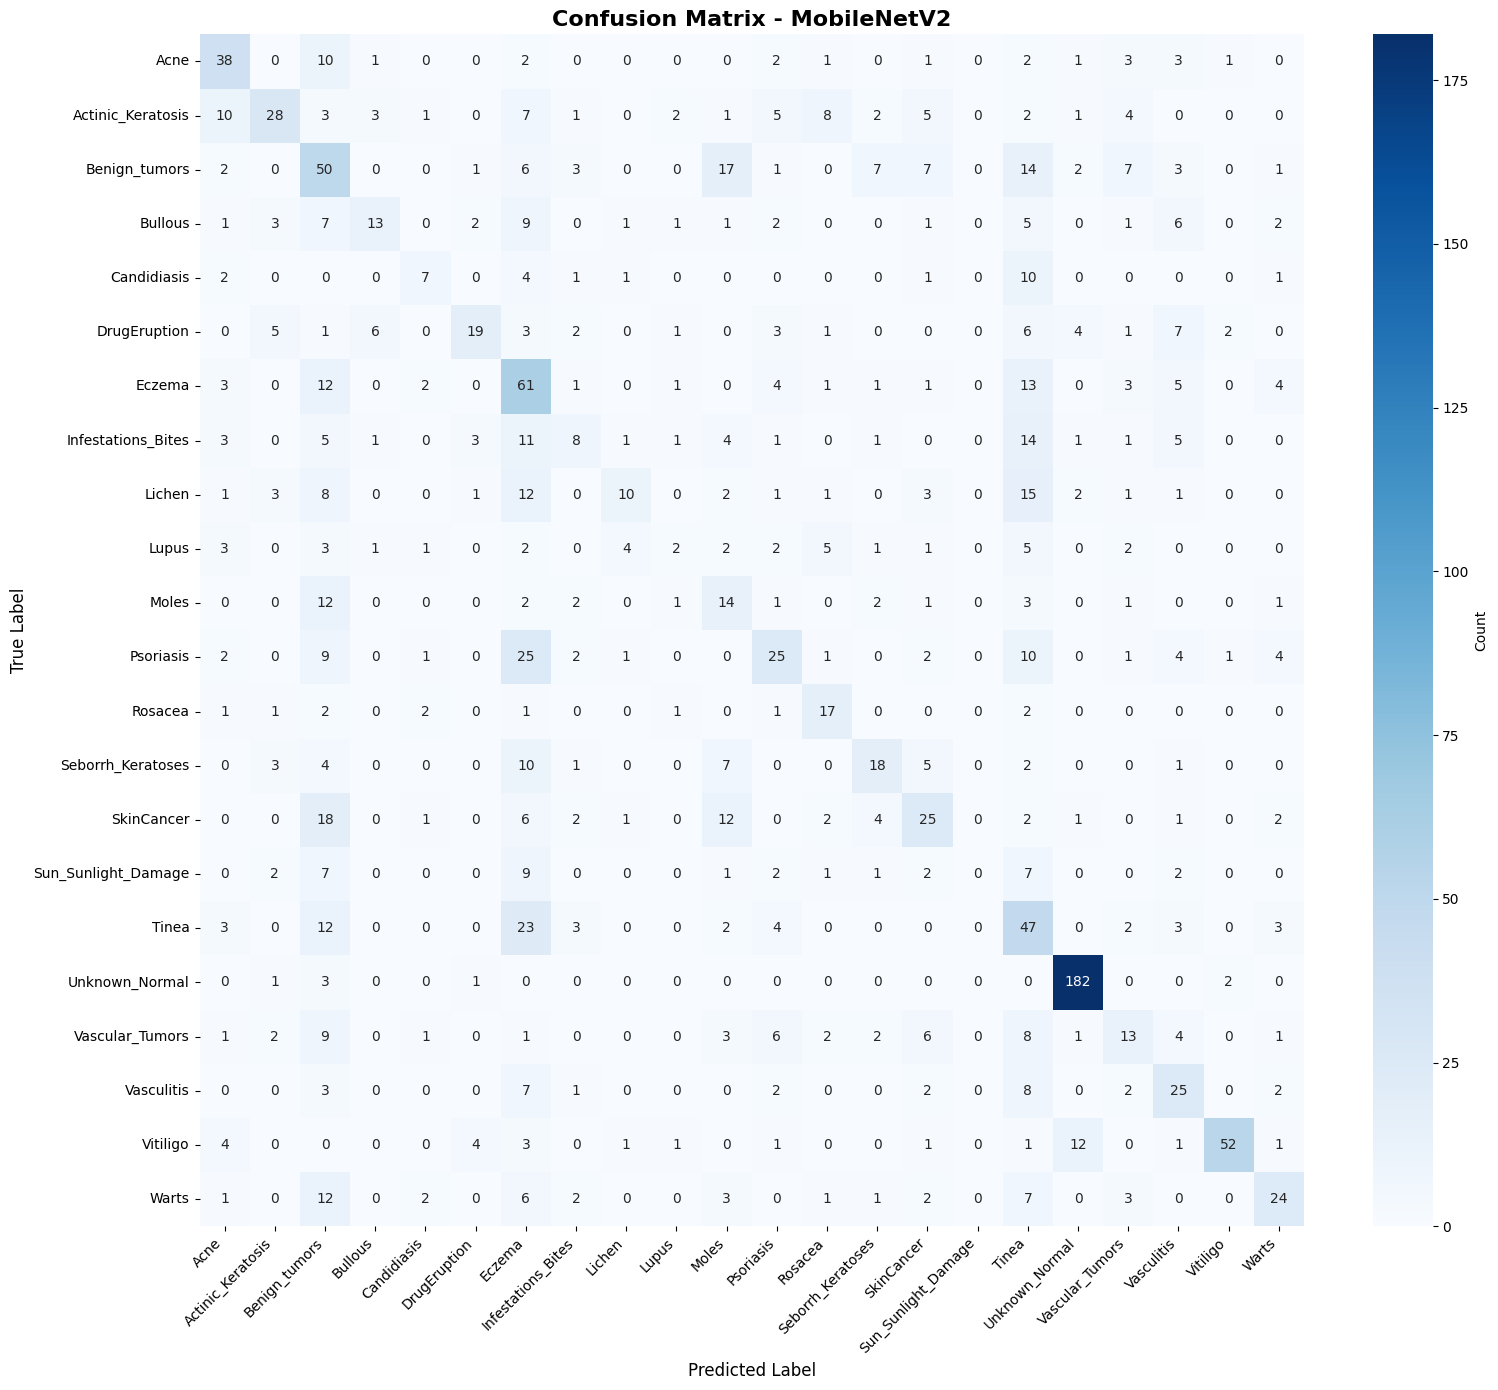

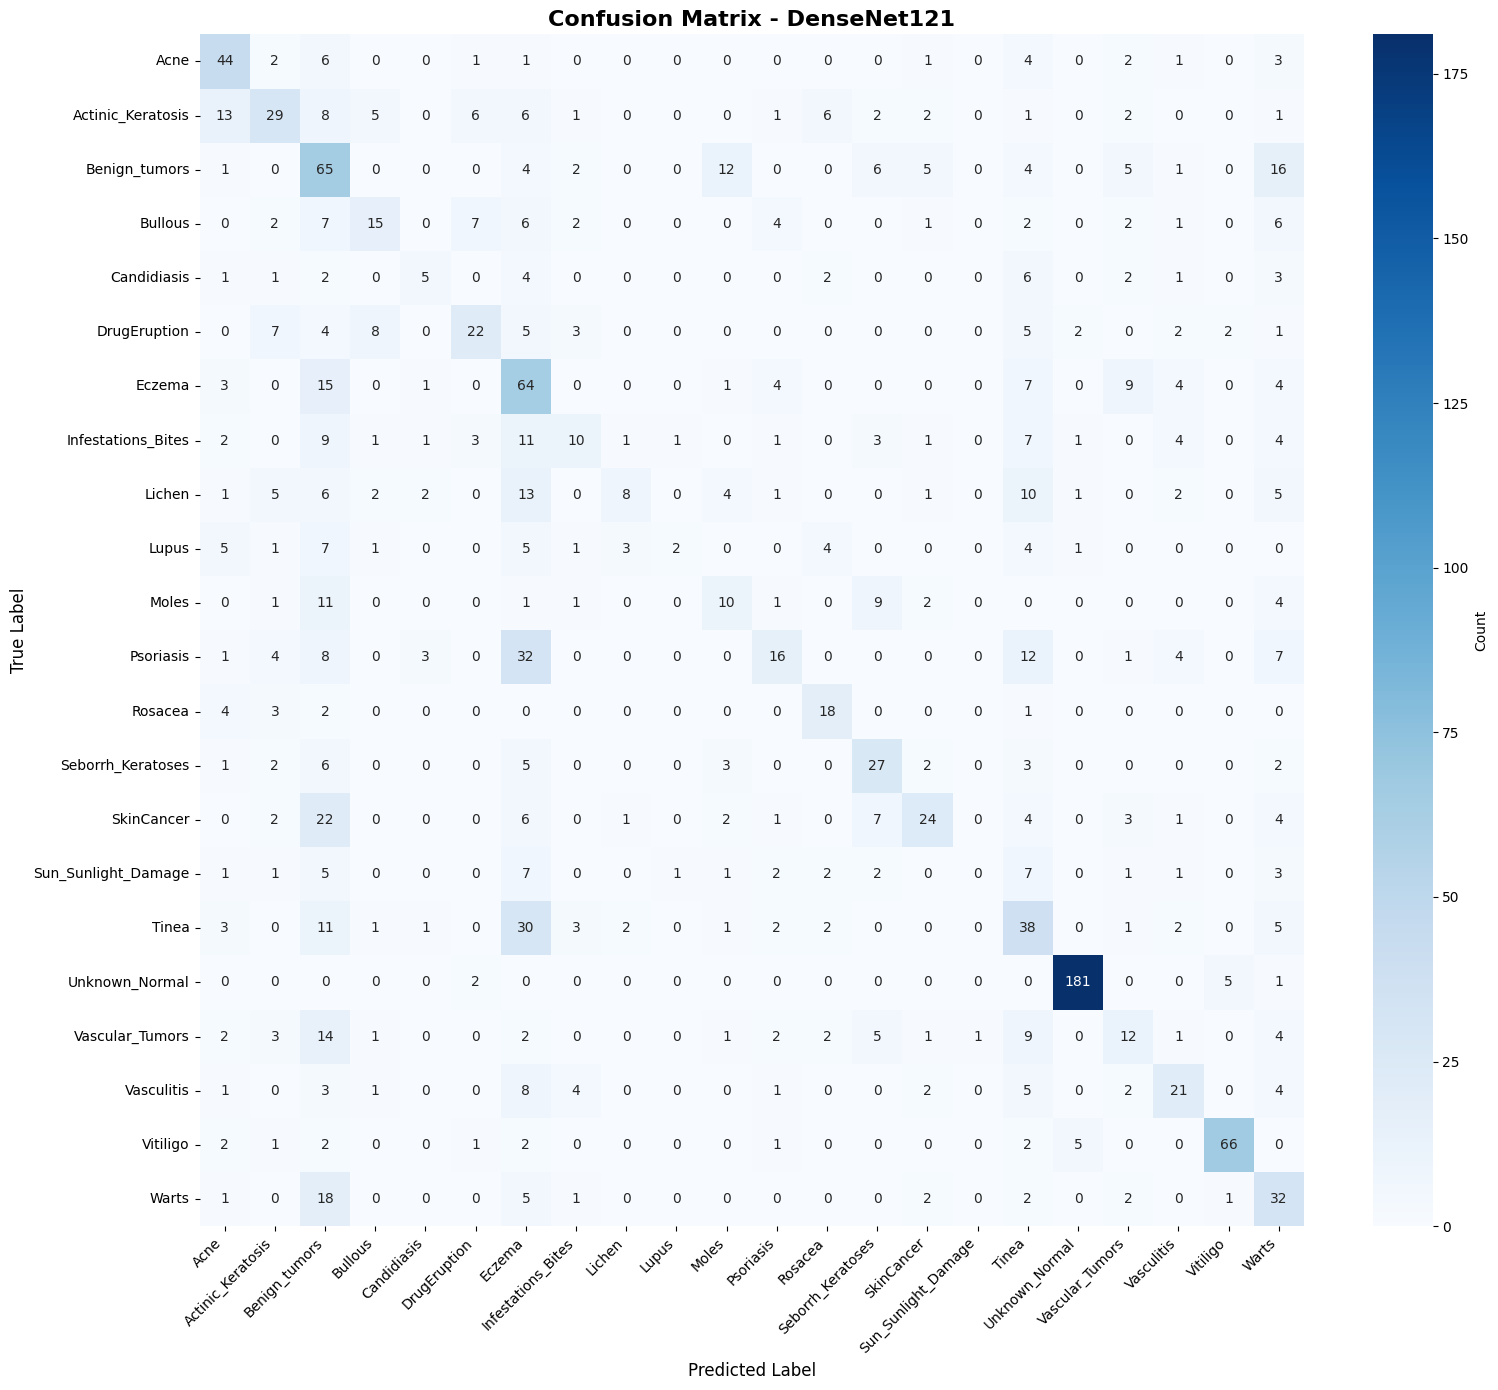

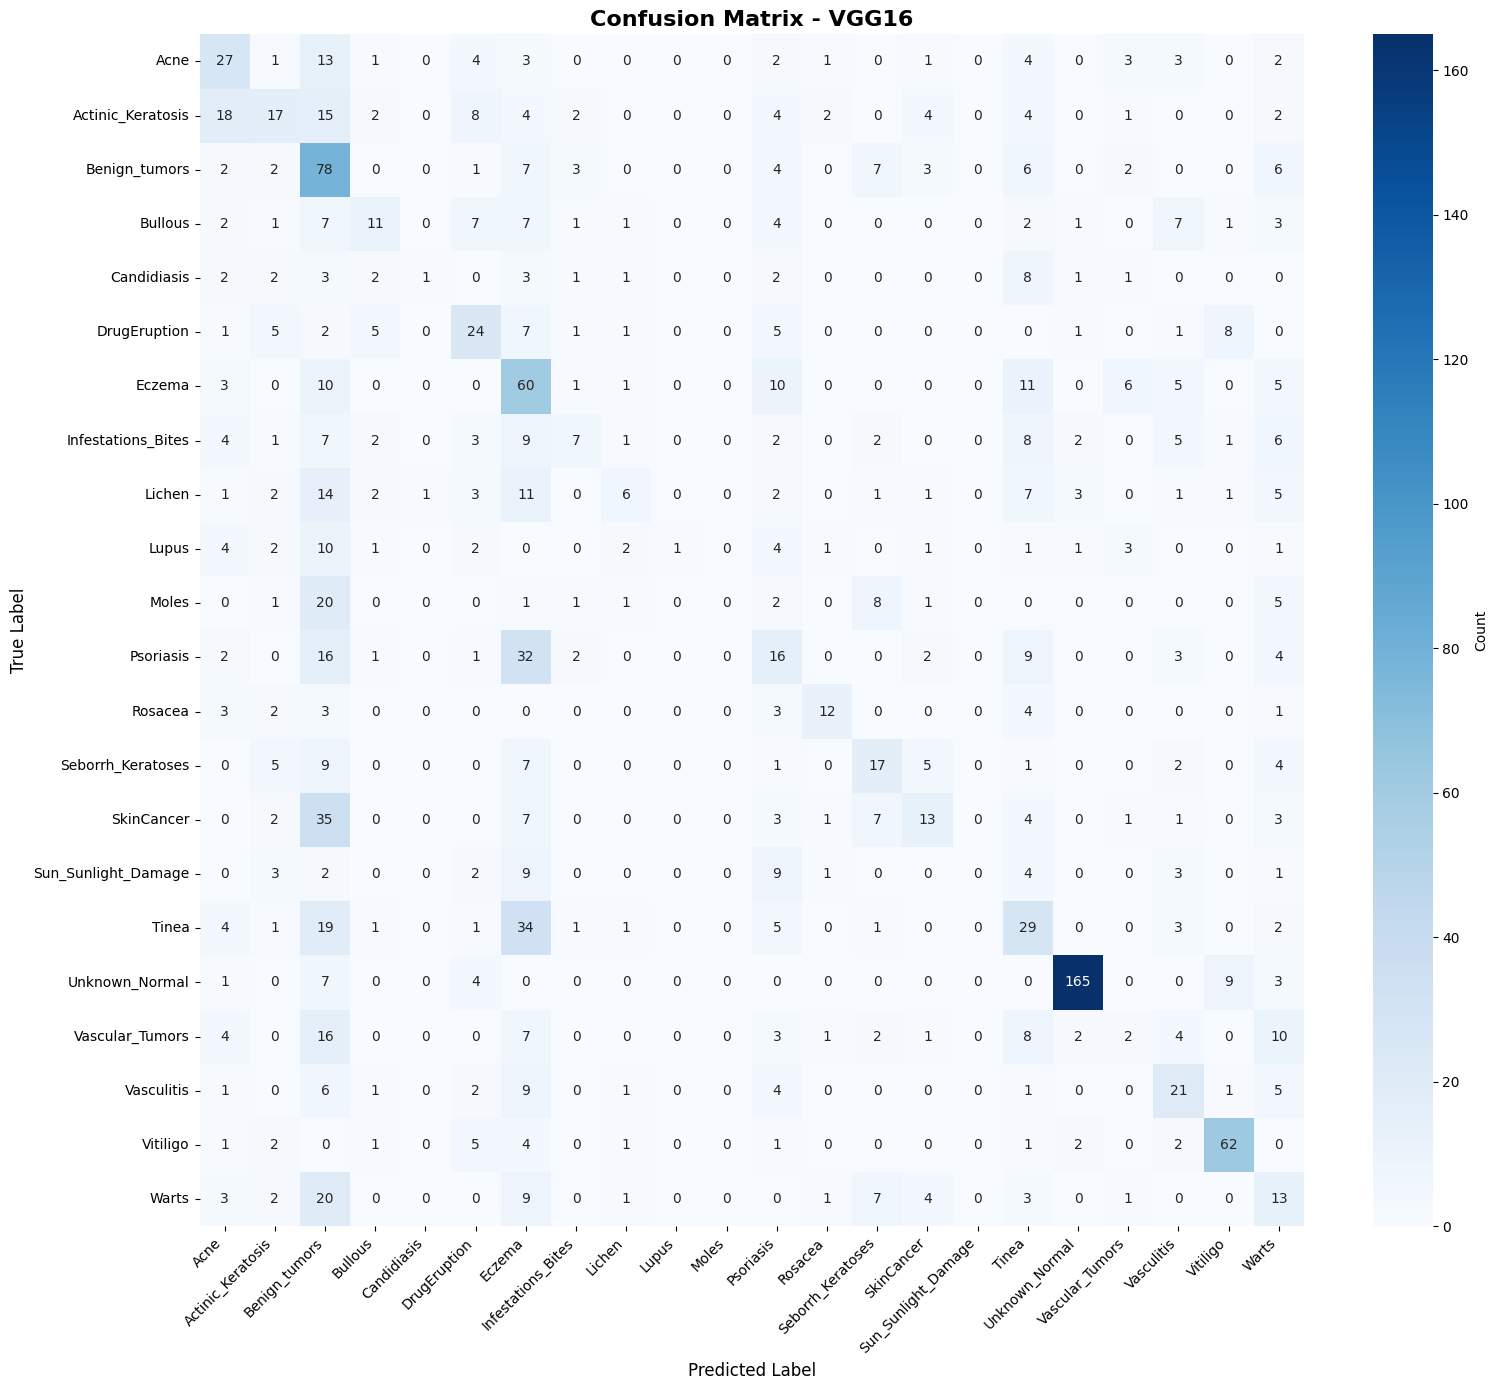

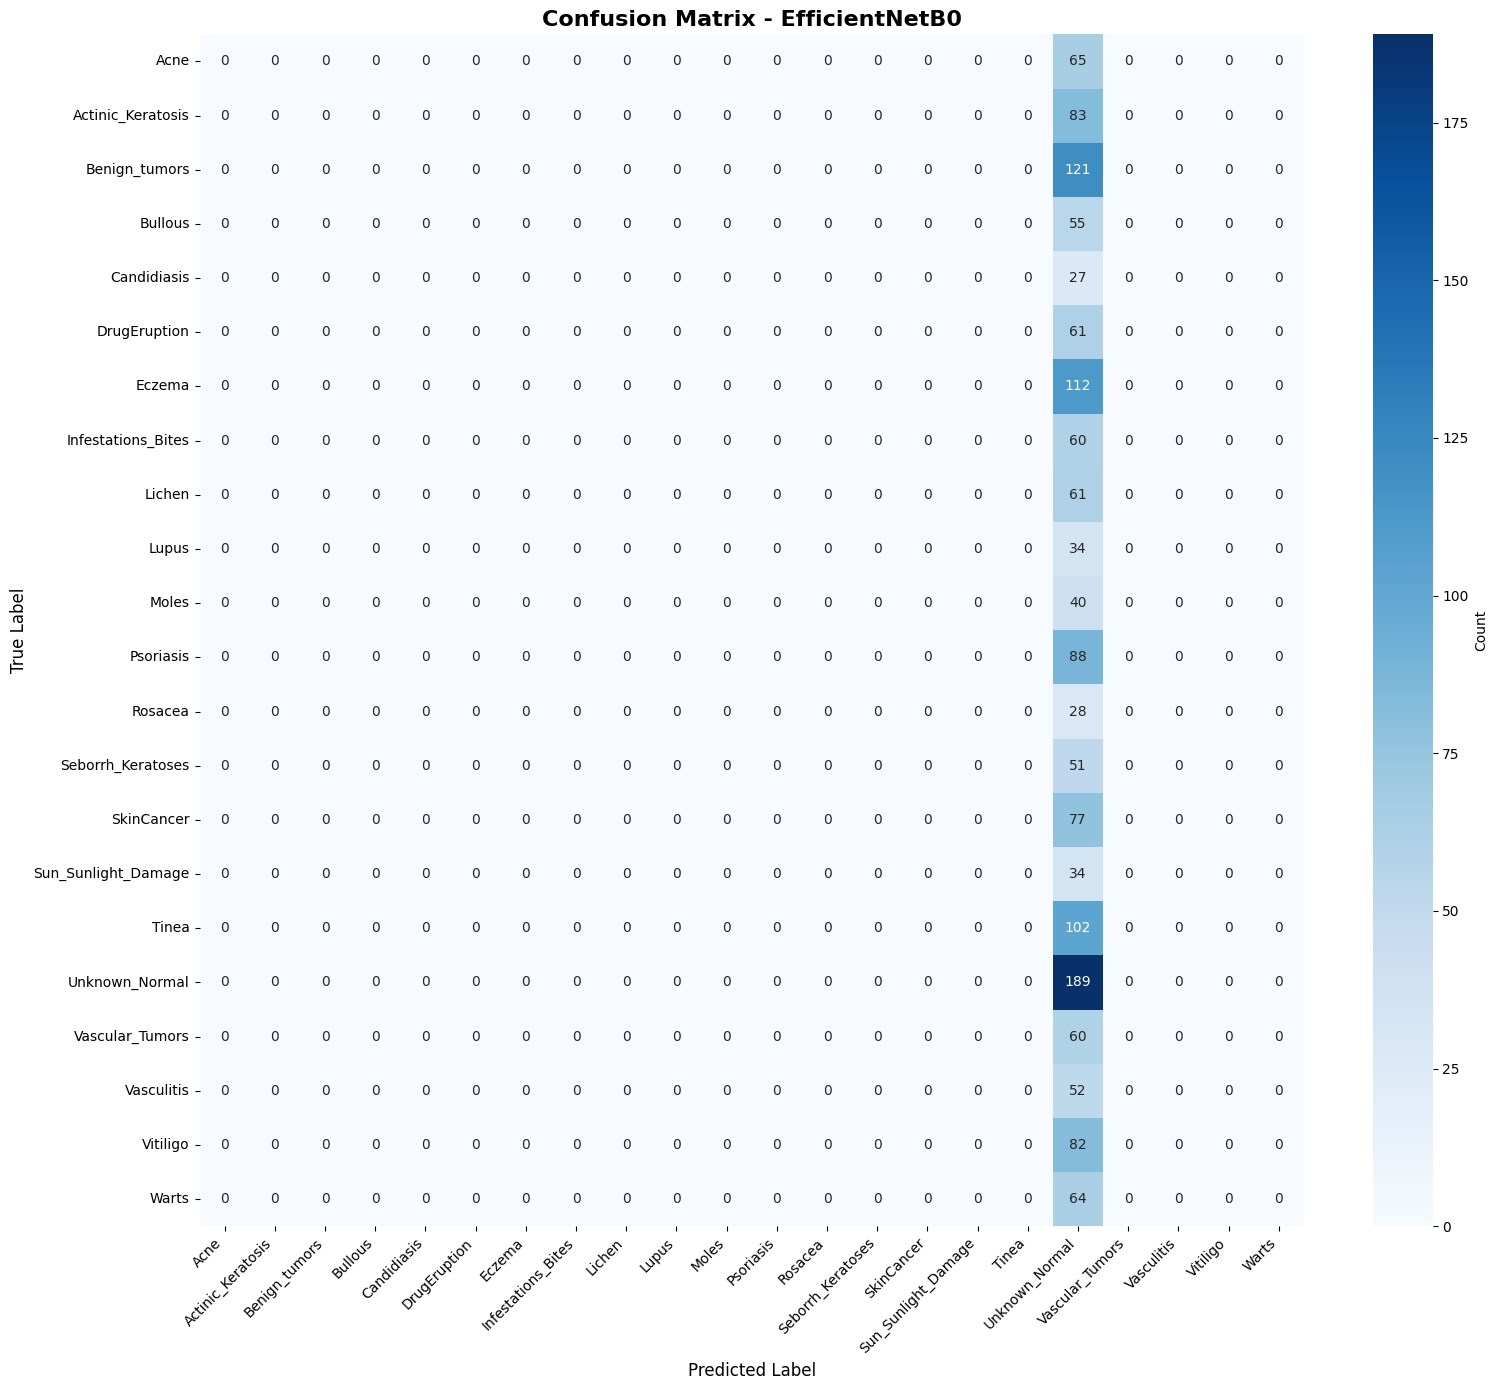

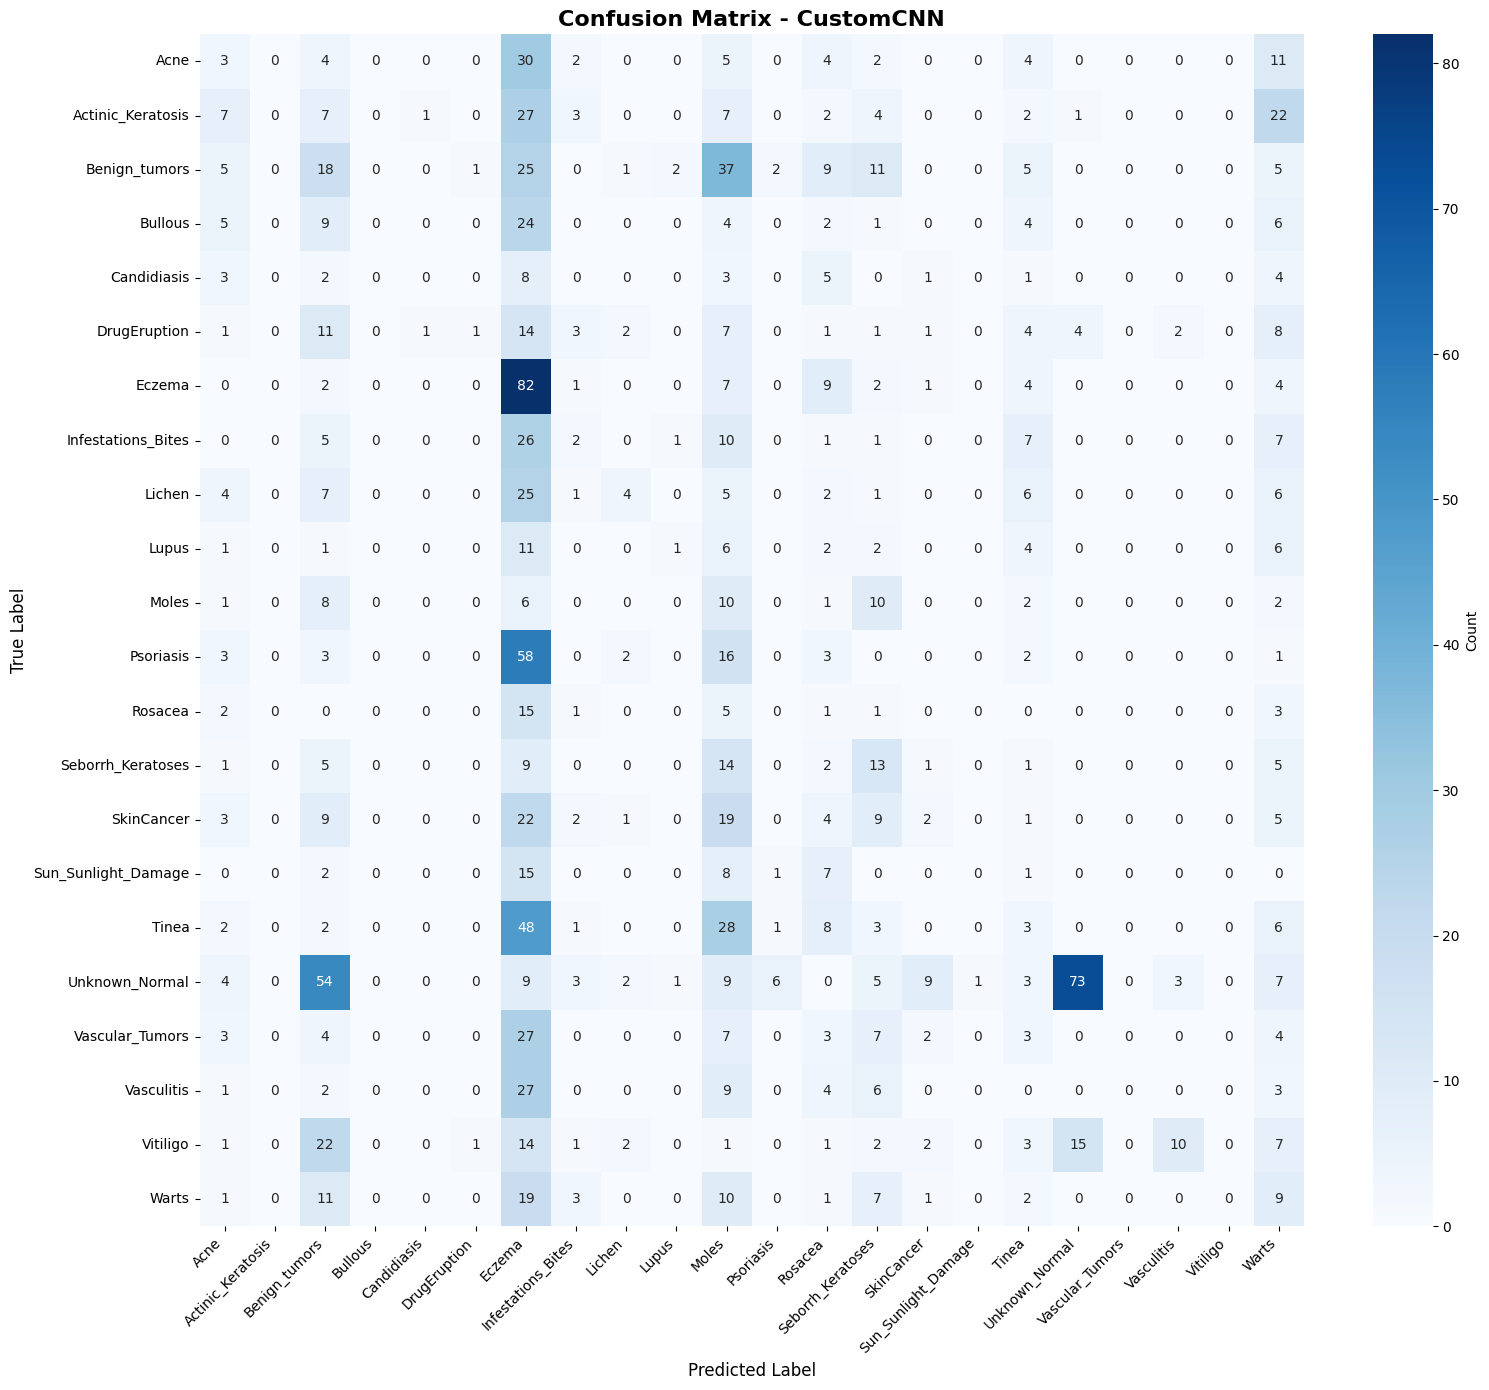

In [20]:
# Plot confusion matrices
def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {model_name}', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Plot confusion matrix for each model
for model_name, data in evaluation_results.items():
    plot_confusion_matrix(
        data['y_true'],
        data['y_pred'],
        model_name,
        class_names
    )


MODEL COMPARISON SUMMARY (GPU-ACCELERATED)

         Model  Test Accuracy  Val Accuracy  Train Accuracy
   DenseNet121       0.458603      0.350903        0.443027
   MobileNetV2       0.438551      0.351625        0.448059
         VGG16       0.376455      0.318051        0.341391
     CustomCNN       0.143596      0.131769        0.274623
EfficientNetB0       0.122251      0.119134        0.115744


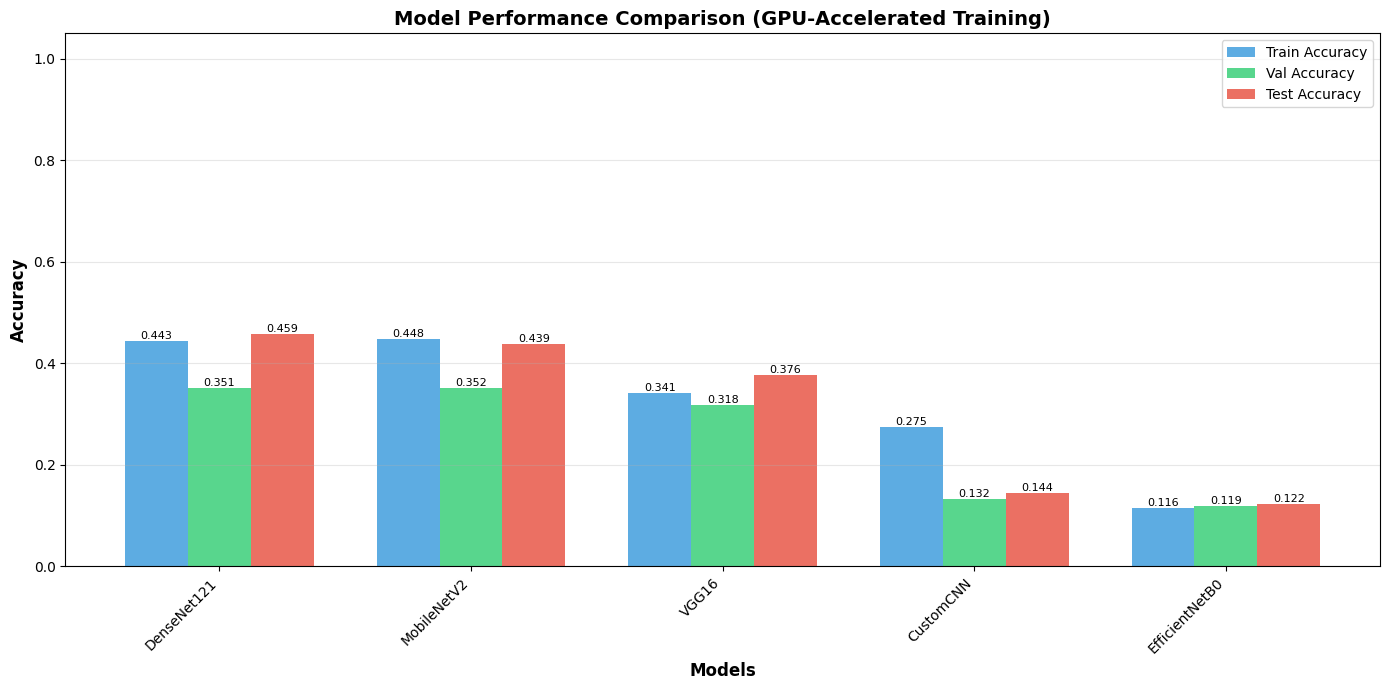


🏆 BEST MODEL: DenseNet121
   Test Accuracy: 0.4586
   Training completed on GPU with CUDA acceleration


In [21]:
# Compare all models
comparison_df = pd.DataFrame({
    'Model': list(evaluation_results.keys()),
    'Test Accuracy': [data['test_accuracy'] for data in evaluation_results.values()],
    'Val Accuracy': [results[name]['history'].history['val_accuracy'][-1] 
                     for name in evaluation_results.keys()],
    'Train Accuracy': [results[name]['history'].history['accuracy'][-1] 
                       for name in evaluation_results.keys()]
})

comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY (GPU-ACCELERATED)")
print("="*60 + "\n")
print(comparison_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(comparison_df))
width = 0.25

bars1 = ax.bar(x - width, comparison_df['Train Accuracy'], width, label='Train Accuracy', alpha=0.8, color='#3498db')
bars2 = ax.bar(x, comparison_df['Val Accuracy'], width, label='Val Accuracy', alpha=0.8, color='#2ecc71')
bars3 = ax.bar(x + width, comparison_df['Test Accuracy'], width, label='Test Accuracy', alpha=0.8, color='#e74c3c')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (GPU-Accelerated Training)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.05])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Best model
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Test Accuracy']
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.4f}")
print(f"   Training completed on GPU with CUDA acceleration")

In [22]:
# Save detailed results
results_summary = {
    'model_name': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': [],
    'epochs_trained': []
}

for model_name, data in results.items():
    results_summary['model_name'].append(model_name)
    results_summary['train_acc'].append(data['history'].history['accuracy'][-1])
    results_summary['val_acc'].append(data['history'].history['val_accuracy'][-1])
    results_summary['test_acc'].append(evaluation_results[model_name]['test_accuracy'])
    results_summary['epochs_trained'].append(len(data['history'].history['accuracy']))

summary_df = pd.DataFrame(results_summary)
summary_df = summary_df.sort_values('test_acc', ascending=False)
summary_df.to_csv('model_comparison_results_cuda.csv', index=False)

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60 + "\n")
print(summary_df.to_string(index=False))

print("\n✅ Results saved to 'model_comparison_results_cuda.csv'")

# Print GPU utilization info
print("\n" + "="*60)
print("GPU TRAINING STATISTICS")
print("="*60)
print(f"Training Device: GPU (CUDA)")
print(f"Mixed Precision: Enabled (float16)")
print(f"Batch Size: {BATCH_SIZE}")
print(f"XLA Optimization: Enabled")
print(f"Total Models Trained: {len(results)}")
print("="*60)


FINAL RESULTS SUMMARY

    model_name  train_acc  val_acc  test_acc  epochs_trained
   DenseNet121   0.443027 0.350903  0.458603              17
   MobileNetV2   0.448059 0.351625  0.438551              16
         VGG16   0.341391 0.318051  0.376455              20
     CustomCNN   0.274623 0.131769  0.143596              10
EfficientNetB0   0.115744 0.119134  0.122251               4

✅ Results saved to 'model_comparison_results_cuda.csv'

GPU TRAINING STATISTICS
Training Device: GPU (CUDA)
Mixed Precision: Enabled (float16)
Batch Size: 32
XLA Optimization: Enabled
Total Models Trained: 5
